In [23]:
import pandas as pd
import matplotlib.pyplot as plt

In [24]:
df = pd.read_csv("../netflix_titles.csv")

df.head()
df.tail()
df.describe()
df.info()
df.shape
df.columns
df.isnull().sum()
df.duplicated().sum()


<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


np.int64(0)

In [25]:
# Fill missing values in categorical columns
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Unknown')
df['duration'] = df['duration'].fillna('Unknown')

# Verify missing values
df.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           0
duration         0
listed_in        0
description      0
dtype: int64

In [27]:
# Convert the date_added column to datetime
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")

# Remove rows with missing or invalid dates
df = df.dropna(subset=["date_added"])

# Extract year and month from date_added
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month_name()

# Display the updated dataset
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,September
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,September
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,September
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021,September
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021,September


Q.1 How many Movies and TV Shows are on Netflix?

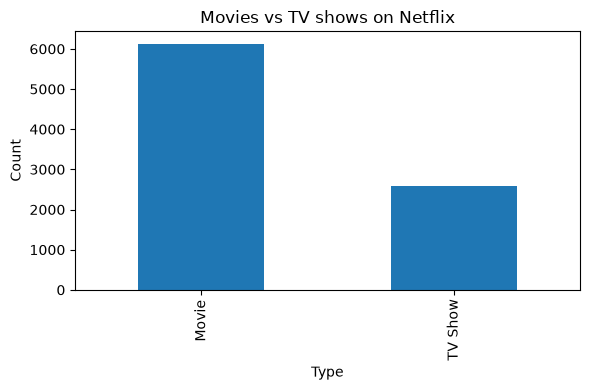

In [ ]:
plt.figure(figsize=(6,4))
df['type'].value_counts().plot(kind = "bar")

plt.title("Movies vs TV shows on Netflix")
plt.xlabel("Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Insight:
 Movies make up the majority of Netflix's content library, indicating that the platform focuses more on films than TV shows.

Q.2 Which year had the most content added?

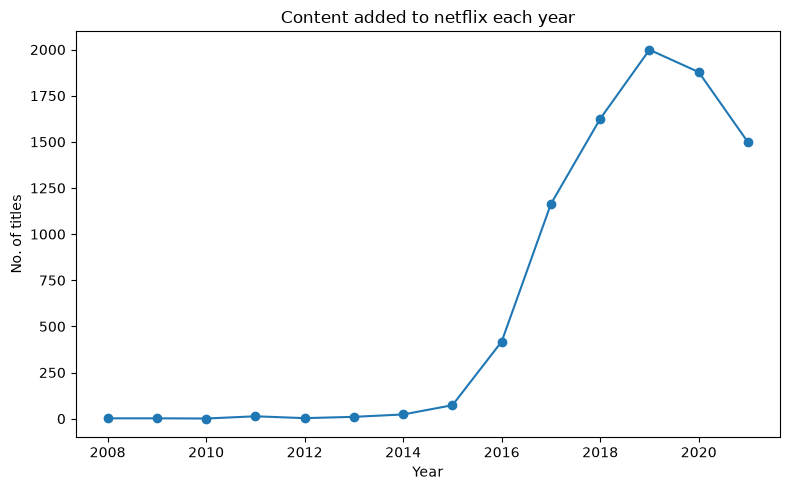

In [32]:
plt.figure(figsize=(8,5))
df['year_added'].value_counts().sort_index().plot(kind = 'line' , marker = 'o')

plt.title("Content added to netflix each year")
plt.xlabel("Year")
plt.ylabel("No. of titles")
plt.tight_layout()
plt.show()

Insight: The number of titles added to Netflix increased steadily over the years, reflecting the platform's rapid expansion

Q.3 Top 10 countries?

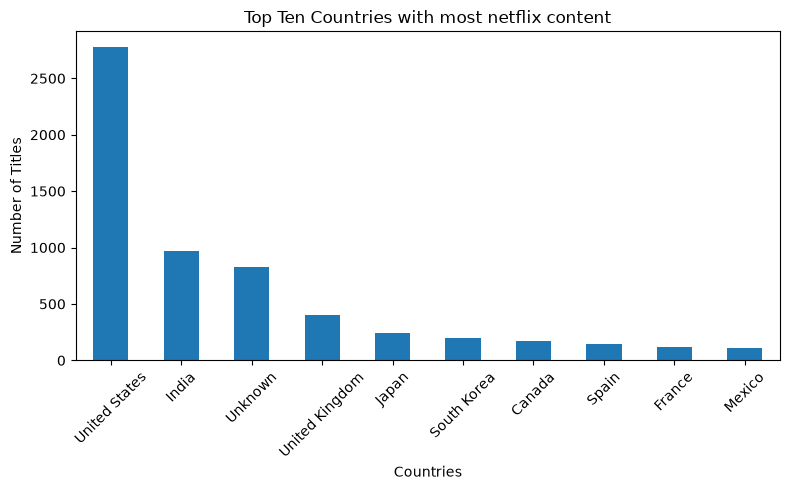

In [ ]:
plt.figure(figsize=(8,5))
df['country'].value_counts().head(10).plot(kind = 'bar')

plt.title("Top 10 Countries with most netflix content")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Insight: The United States contributes the highest number of titles on Netflix, followed by other countries, highlighting Netflix's strong presence in major content-producing markets.

Q.4 Top 10 Directors?



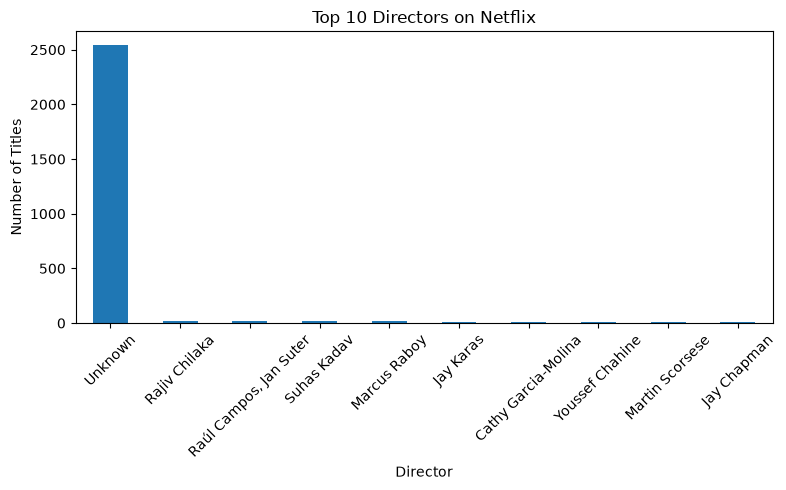

In [35]:
plt.figure(figsize=(8,5))
df['director'].value_counts().head(10).plot(kind = 'bar')

plt.title("Top 10 Directors on Netflix")
plt.xlabel('Director')
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Insight: A few directors have multiple titles on Netflix, while most directors contribute only a small number of titles, showing a diverse creator base.

Q.5 Most Common Ratings

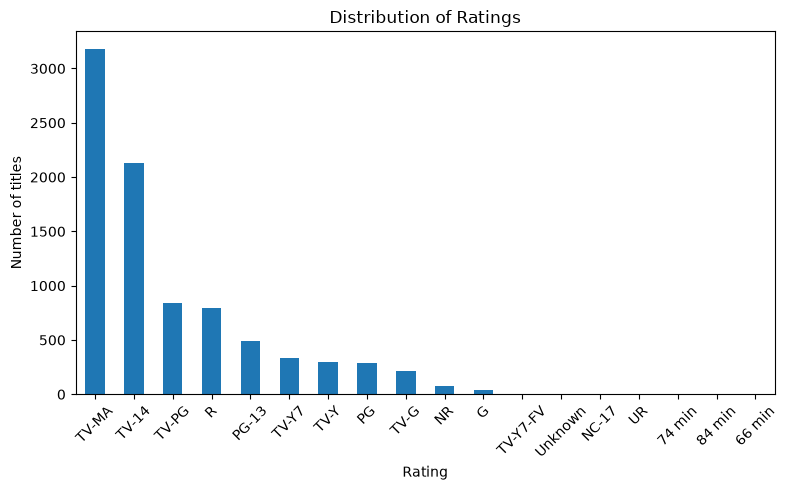

In [36]:
plt.figure(figsize=(8,5))
df['rating'].value_counts().plot( kind= 'bar')

plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of titles")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

Insight: Ratings such as TV-MA and TV-14 are the most common, suggesting that Netflix primarily targets mature and teenage audiences

Q.6 Most Popular Genres

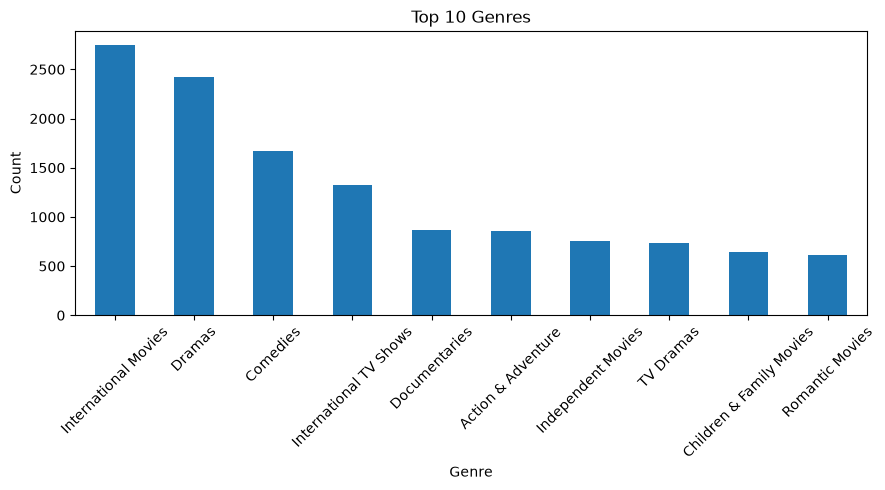

In [38]:
plt.figure(figsize=(9,5))
genres = df['listed_in'].str.split(", ").explode()
genres.value_counts().head(10).plot( kind = "bar")

plt.title("Top 10 Genres")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Insight: Genres like International Movies, Dramas, and Comedies dominate Netflix's catalog, reflecting a diverse and globally oriented content library

Q.7 Movies Released Every Year

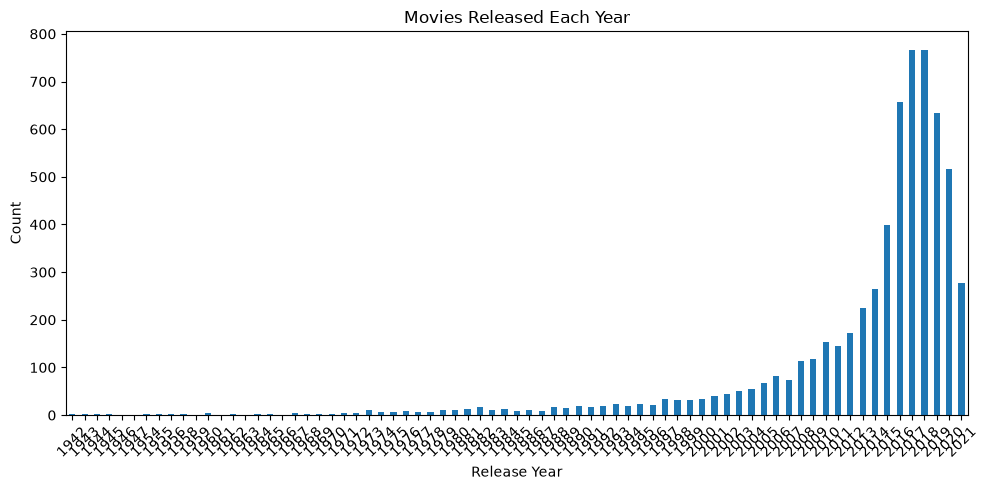

In [40]:
plt.figure(figsize=(10,5))
movies = df[df['type'] == "Movie"]
movies["release_year"].value_counts().sort_index().plot( kind = "bar")

plt.title("Movies Released Each Year")
plt.xlabel("Release Year")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Insight: Most movies available on Netflix were released in recent years, indicating the platform's emphasis on modern and recently produced content.

In [42]:
# Save the cleaned dataset
df.to_csv("data/cleaned_netflix_data.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
